<a href="https://colab.research.google.com/github/AmedeeRoy/BirdGAN/blob/main/GAN_cnn_matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN

In [1]:
# mount google drive
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
%cd drive/My\ Drive/

/content/drive/My Drive


## load data

In [3]:
# import python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import datetime as dt
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, Dataset
import torchvision as tv

torch.manual_seed(17)

In [4]:
data_train = pd.read_table('./data/trips_SV_train.csv', sep = ',')
data_train['datetime'] = pd.to_datetime(data_train['datetime'], format='%Y-%m-%d %H:%M:%S')

data_test = pd.read_table('./data/trips_SV_test.csv', sep = ',')
data_test['datetime'] = pd.to_datetime(data_test['datetime'], format='%Y-%m-%d %H:%M:%S')

In [5]:
with open("./data/external_data", "rb") as input_file:
  external_data = pickle.load(input_file)

def subset_external_data(external_data, t):
  
  t = dt.datetime(t.year, t.month, t.day, 12, 0,0)
  subset_data = external_data
  
  # get index
  i_chl = np.argwhere(external_data['chl'][0] == t.date())
  i_sst = np.argwhere(external_data['sst'][0] == t.date())
  i_wind = np.argwhere(external_data['wind'][0] == t)
  i_ac = np.argwhere(external_data['acoustic'][0] == t.year)
  
  # subset
  labels = ['lon', 'lat', 'chl', 'sst', 'wind_u', 'wind_v', 'acoustic', 'bathy']
  
  maps = [external_data['lon'],external_data['lat'],
          external_data['chl'][1][i_chl,:,:].squeeze()/20,
          (external_data['sst'][1][i_sst,:,:].squeeze()-17)/2,
          external_data['wind'][1][0][i_wind,:,:].squeeze()/5,
          external_data['wind'][1][1][i_wind,:,:].squeeze()/5,
          external_data['acoustic'][1][i_ac,:,:].squeeze()/8e3,
          -external_data['bathy'][1]/500]
      
  return (labels, maps)

In [6]:
class TrajDataSet(Dataset):
    def __init__(self,  df, external, transform=None):
        self.df = df   # save trips
        self.external = external # save covariables
        self.trip = df.trip.unique() # list of trips
        self.length_max = max([np.sum(self.df.trip == t) for t in self.trip])

        self.transform = transform

    def __len__(self):
        return len(self.trip)

    def __getitem__(self, idx):
        i = self.trip[idx]
        traj = self.df[self.df.trip == i].copy()
        time = min(traj.datetime)

        # select coordinates
        coord = traj.loc[:,('lon_std', 'lat_std')].to_numpy()
        ext = subset_external_data(self.external, time)
        cov = np.stack(ext[1][2:])
        cov[np.isnan(cov)] = 0

        sample = (cov, coord)

        if self.transform:
            sample = self.transform(sample)

        return sample

class DistMatrix(object):
    """Convert Trajectory to Distance Matrix"""

    def __call__(self, sample):
        cov, coord = sample
        
        # change resolution
        grid_x, grid_y = np.meshgrid(coord[:,0], coord[:,1])
        dd = (grid_x-grid_x.T)**2 + (grid_y - grid_y.T)**2

        return (cov, dd)

class Resolution(object):
    """Reduce temporal resolution of trajectory"""
    def __init__(self, nb):
            self.nb = nb

    def __call__(self, sample):
        cov, coord = sample
        # change resolution
        coord_new = coord[np.arange(0, coord.shape[0], self.nb),:]
        return (cov, coord_new)

class Padding(object):
    """Pad trajectories with zeros"""
    def __init__(self, nb):
            self.nb = nb

    def __call__(self, sample):
        cov, coord = sample
        # change resolution
        coord_new = np.zeros((self.nb,2))
        coord_new[:coord.shape[0],:] = coord

        return (cov, coord_new)

class ToTensor(object):
    """Convert ndarrays in sample to Tensors."""

    def __call__(self, sample):
        (cov,coord) = sample
        return (torch.FloatTensor(cov), torch.FloatTensor(coord.T))

In [7]:
# hyperparameters
batch_size = 12
resolution = 4
padding = 256

## reduce size dataset
train_set = TrajDataSet(data_train, external_data, transform= tv.transforms.Compose([Resolution(resolution), Padding(padding), ToTensor()]))
train_loader = DataLoader(train_set, batch_size=batch_size, num_workers = 0, shuffle = True, drop_last=True)

In [8]:
x,y =  next(iter(train_loader))

In [9]:
y.shape

torch.Size([12, 2, 256])

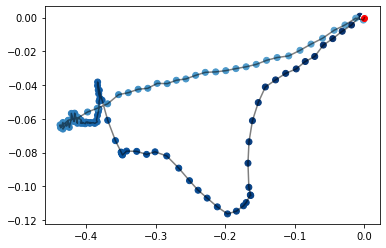

In [10]:
i = 1

plt.plot(y.numpy()[i,0,:], y.numpy()[i,1,:], c = 'black', alpha = 0.5)
plt.scatter(y.numpy()[i,0,:], y.numpy()[i,1,:], c=np.arange(256), cmap='Blues_r')
plt.scatter(0,0, c = 'red')

## deep networks

Architecture guidelines for stable Deep Convolutional GANs (Radford et al. 2016)

- Replace any pooling layers with strided convolutions (discriminator) and fractional-strided
convolutions (generator).
- Use batchnorm in both the generator and the discriminator.
- Remove fully connected hidden layers for deeper architectures.
- Use ReLU activation in generator for all layers except for the output, which uses Tanh.
- Use LeakyReLU activation in the discriminator for all layers.



In [11]:
import torch
from torch import nn
from torch import optim
import torchvision as tv
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [12]:
class CNNGenerator(nn.Module):
    """An LSTM based generator. It expects a sequence of noise vectors as input.
    Args:
        in_dim: Input noise dimensionality
        out_dim: Output dimensionality
        n_layers: number of lstm layers
        hidden_dim: dimensionality of the hidden layer of lstms
    Input: noise of shape (batch_size, seq_len, in_dim)
    Output: sequence of shape (batch_size, seq_len, out_dim)
    """

    def __init__(self):
        super().__init__()

        self.covariable_encoder = nn.Sequential(nn.BatchNorm1d(6), 
                                                nn.Linear(9*7, 4))
        
        self.cnn = nn.Sequential(
            nn.ConvTranspose1d(320, 128, kernel_size = 6, stride = 4, padding = 1, dilation = 1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            
            nn.ConvTranspose1d(128, 32, kernel_size = 6, stride = 4, padding = 1, dilation = 1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            nn.ConvTranspose1d(32, 2, kernel_size = 6, stride = 4, padding = 1, dilation = 1),
            nn.BatchNorm1d(2),
            nn.Tanh()
         )
        

    def forward(self, x, z):
        # covariable maps as vector  (seq_len, batch, input_size)
        out = x.reshape((12, 6, 9*7))
        out = self.covariable_encoder(out)
        
        # concatenate noise and condition
        out = torch.cat((out,z), axis = 1)
        out = out.repeat(1, 20, 1)
        

        # convolutions
        out = self.cnn(out)

        return out

In [13]:
gen = CNNGenerator()
z = torch.rand((batch_size, 10, 4)) # (len, batch, features)

out = gen(x,z)
out.shape

torch.Size([12, 2, 256])

In [14]:
class CNNDiscriminator(nn.Module):
    """An LSTM based discriminator. It expects a sequence as input and outputs a probability for each element. 
    Args:
        in_dim: Input noise dimensionality
        n_layers: number of lstm layers
        hidden_dim: dimensionality of the hidden layer of lstms
    Inputs: sequence of shape (batch_size, seq_len, in_dim)
    Output: sequence of shape (batch_size, seq_len, 1)
    """

    def __init__(self):
        super().__init__()

        self.covariable_encoder = nn.Sequential(nn.BatchNorm1d(6), 
                                                nn.Linear(9*7, 4))
        
        self.cnn_1_mat = nn.Sequential(
            nn.Conv2d(1, 16,  kernel_size = 6, stride = 4, padding = 1, dilation = 1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(),

            nn.Conv2d(16, 32,  kernel_size = 6, stride = 4, padding = 1, dilation = 1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),

            nn.Conv2d(32, 64,  kernel_size = 6, stride = 4, padding = 1, dilation = 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU()
        )

        self.cnn_1_dt = nn.Sequential(
            nn.Conv1d(2, 16,  kernel_size = 6, stride = 4, padding = 1, dilation = 1),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(),
            
            nn.Conv1d(16, 32,  kernel_size = 6, stride = 4, padding = 1, dilation = 1),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(),
            
            nn.Conv1d(32, 64,  kernel_size = 6, stride = 4, padding = 1, dilation = 1),
            nn.BatchNorm1d(64),
            nn.LeakyReLU()
        )
        
        self.cnn_2 = nn.Sequential(
            nn.Conv1d(134, 64,  kernel_size = 2, stride = 4, padding = 1, dilation = 1),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(),

            nn.Conv1d(64, 1,  kernel_size = 2, stride = 4, padding = 1, dilation = 1),
            nn.BatchNorm1d(1),
            nn.Sigmoid()
        )

    def to_matrix(self, y):
      grid_x = y[:,0,:].unsqueeze(1).repeat(1, 256, 1)
      grid_y = y[:,1,:].unsqueeze(1).repeat(1, 256, 1)
 
      dd = (grid_y.transpose(1,2) - grid_y)**2 + (grid_x.transpose(1,2) - grid_x)**2
      return dd.unsqueeze(1)


    def forward(self, x,y):

        # dt
        out_dt = self.cnn_1_dt(y)

        # to matrix
        out_mat = self.to_matrix(y)
        out_mat = self.cnn_1_mat(out_mat)

        out_mat = torch.sum(out_mat, 3)

        # covariable maps
        out_cov = x.reshape((12, 6, 9*7))
        out_cov = self.covariable_encoder(out_cov)

        out = torch.cat((out_mat, out_dt, out_cov), axis = 1)

        out = self.cnn_2(out)
        return out.squeeze(1)


In [15]:
dis = CNNDiscriminator()

In [16]:
dis(x,y).shape

torch.Size([12, 1])

# training

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 12
lr = 0.01
generator = CNNGenerator().to(device)
discriminator = CNNDiscriminator().to(device)

criterion = nn.BCELoss()
mse = nn.MSELoss()

optim_d = optim.Adam(discriminator.parameters(), lr=lr)
optim_g = optim.Adam(generator.parameters(),lr=lr)

target_ones = torch.ones((batch_size, 1), device=device)
target_zeros = torch.zeros((batch_size, 1), device=device)

In [21]:
# Train the model
nb_epoch = 30

for epoch in range(nb_epoch):
    i = 0

    # if epoch%10 == 0:
    #     lr /= 10
    #     optim_d = optim.Adam(discriminator.parameters(), lr=lr)
    #     optim_g = optim.Adam(generator.parameters(),lr=lr)

    loss_g_running, loss_d_real_running, loss_d_fake_running = 0, 0, 0
    for batch, (x, y) in enumerate(train_loader):
        
        i+= 1
        #### TRAIN DISCRIMINATOR
        ## true samples
        x = x.to(device)
        y = y.to(device) 

        discriminator.zero_grad()
        pred_real = discriminator(x,y)
        loss_real = criterion(pred_real, target_ones)

        ## false samples
        z = torch.rand((batch_size, 10, 4), device=device) 
        with torch.no_grad():
            fake_samples = generator(x,z)
        pred_fake = discriminator(x, fake_samples)
        loss_fake = criterion(pred_fake, target_zeros)
        
        # combine
        loss = (loss_real + loss_fake) / 2
        loss.backward()
        optim_d.step()

        loss_d_real_running += loss_real.item()
        loss_d_fake_running += loss_fake.item()
        
        #### TRAIN GENERATOR
        generator.zero_grad()
        z = torch.rand((batch_size, 10, 4), device=device) 

        generated = generator(x,z)
        classifications = discriminator(x, generated)
        loss = criterion(classifications, target_ones)
        loss.backward()
        optim_g.step()

        loss_g_running += loss.item()
      
    print('Epoch [{}/{}] -----------------------------------------------------------------------------'
        .format(epoch+1, nb_epoch, i, len(train_loader)))
    print('G: {}, Dr : {}, Df : {}'
        .format(loss_g_running, loss_d_real_running, loss_d_fake_running))



Epoch [1/30] -----------------------------------------------------------------------------
G: 15.69785225391388, Dr : 15.764633119106293, Df : 17.09436410665512
Epoch [2/30] -----------------------------------------------------------------------------
G: 15.153163492679596, Dr : 15.137823820114136, Df : 16.256745755672455
Epoch [3/30] -----------------------------------------------------------------------------
G: 14.926339149475098, Dr : 14.927073180675507, Df : 15.52393627166748
Epoch [4/30] -----------------------------------------------------------------------------
G: 14.793765187263489, Dr : 14.803710341453552, Df : 14.987079679965973
Epoch [5/30] -----------------------------------------------------------------------------
G: 14.661329567432404, Dr : 14.675182163715363, Df : 14.710801780223846
Epoch [6/30] -----------------------------------------------------------------------------
G: 14.598346889019012, Dr : 14.600777804851532, Df : 14.610801219940186
Epoch [7/30] ------------

## visualizing

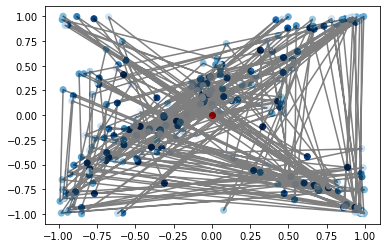

In [22]:
i = 10

traj = generated.detach().numpy()

plt.plot(traj[i,0,:], traj[i,1,:], c = 'black', alpha = 0.5)
plt.scatter(traj[i,0,:], traj[i,1,:], c=np.arange(256), cmap='Blues_r')
plt.scatter(0,0, c = 'red')